# Map query data onto a reference

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/tutorials/query_mapping.ipynb)

A common situation: you have a paired multimodal **reference**, and new **query** data where only one modality was measured (scRNA-seq only, or scATAC-seq only). Because each modality has its own encoder into a shared latent space, UniVI can place query cells next to the reference without retraining. This is the approach used for the bridge analyses in the paper (Figs. 5 and 7).

To be able to check the answers, we build the scenario from the Multiome PBMC data:

- the **reference** is 70% of cells, with RNA and ATAC
- the remaining cells are split into an **RNA-only query** and an **ATAC-only query** (we hide the other modality, but keep it for evaluation)
- one cell type is **left out of the reference entirely**, to show how to recognize cells the reference has never seen

You will transfer labels to the queries, estimate confidence, and predict the missing modality.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.0" "pandas==2.2.3"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import cross_modal_predict, encode_adata, encode_fused_adata_pair, pearson_corr_per_feature
from univi.plotting import plot_confusion_matrix
from univi.preprocessing import ATACPreprocessor, RNAPreprocessor
from univi.utils.seed import set_seed
from univi.workflows import make_loader, stack_embeddings

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)

C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 400
BATCH_SIZE = 256
N_HVG = 2000
N_LSI = 101
HOLDOUT_TYPE = "pDC"   # a cell type kept out of the reference

## Build reference and query cohorts

In [4]:
data = uds.pbmc_multiome_10k()
rna, atac = data["rna"], data["atac"]
cell_type = rna.obs["cell_type"].astype(str)

rng = np.random.default_rng(0)
is_query = rng.random(rna.n_obs) < 0.30
is_query |= (cell_type == HOLDOUT_TYPE).to_numpy()          # the held-out type only appears in queries
query_idx = np.flatnonzero(is_query)
rng.shuffle(query_idx)
rna_only_idx, atac_only_idx = np.sort(query_idx[::2]), np.sort(query_idx[1::2])
ref_idx = np.flatnonzero(~is_query)

print(f"reference {len(ref_idx)} cells (RNA + ATAC); RNA-only query {len(rna_only_idx)}; ATAC-only query {len(atac_only_idx)}")
print(f"{HOLDOUT_TYPE} cells in reference: {(cell_type.iloc[ref_idx] == HOLDOUT_TYPE).sum()}")

reference 6668 cells (RNA + ATAC); RNA-only query 1482; ATAC-only query 1481
pDC cells in reference: 0


## Train the reference

Preprocessing is fit on reference training cells. Everything downstream (validation cells and both queries) is transformed with the same fitted objects, exactly as you would do for data collected later.

In [5]:
ref_rna, ref_atac = rna[ref_idx].copy(), atac[ref_idx].copy()
perm = rng.permutation(len(ref_idx))
val_cells, train_cells = np.sort(perm[: len(perm) // 10]), np.sort(perm[len(perm) // 10:])  # 90/10

rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=True).fit(ref_rna[train_cells])
atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=True, scale=True).fit(ref_atac[train_cells])

ref = {"rna": rna_prep.transform(ref_rna), "atac": atac_prep.transform(ref_atac)}
train = {m: a[train_cells] for m, a in ref.items()}
val = {m: a[val_cells] for m, a in ref.items()}

cfg = UniVIConfig(
    latent_dim=30, beta=1.25, gamma=4.35, encoder_dropout=0.10, decoder_dropout=0.05,
    kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110,
    modalities=[
        ModalityConfig("rna", train["rna"].n_vars, [512, 256, 128], [128, 256, 512]),
        ModalityConfig("atac", train["atac"].n_vars, [128, 64], [64, 128]),
    ],
)
model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
UniVITrainer(
    model,
    train_loader=make_loader(train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
    val_loader=make_loader(val, batch_size=1024),
    train_cfg=TrainingConfig(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4, device=device,
                             early_stopping=True, patience=50, best_epoch_warmup=110, log_every=50),
).fit();

[2026-09-20 21:11:22,075] [UniVITrainer] [INFO] TrainingConfig:


[2026-09-20 21:11:22,076] [UniVITrainer] [INFO]   n_epochs: 400


[2026-09-20 21:11:22,076] [UniVITrainer] [INFO]   batch_size: 256


[2026-09-20 21:11:22,076] [UniVITrainer] [INFO]   lr: 0.001


[2026-09-20 21:11:22,077] [UniVITrainer] [INFO]   weight_decay: 0.0001


...

Training UniVI:  40%|████      | 162/400 [3:29:48<5:01:04, 75.90s/it, beta=1.250, gamma=4.350, train_loss=895.3164, val_loss=899.7950]

Training UniVI:  40%|████      | 162/400 [3:31:04<5:01:04, 75.90s/it, beta=1.250, gamma=4.350, train_loss=894.6737, val_loss=899.8857]

[2026-09-21 00:42:26,325] [UniVITrainer] [INFO] Early stopping at epoch 163 (best val loss=897.5375, best epoch=113)


Training UniVI:  40%|████      | 162/400 [3:31:04<5:10:05, 78.17s/it, beta=1.250, gamma=4.350, train_loss=894.6737, val_loss=899.8857]


[2026-09-21 00:42:26,359] [UniVITrainer] [INFO] Restored best model from epoch 113 (val loss=897.5375)


## Preprocess and embed the queries

Queries go through the reference's fitted preprocessors, then through the encoder of the one modality they have.

In [6]:
q_rna = rna_prep.transform(rna[rna_only_idx])
q_atac = atac_prep.transform(atac[atac_only_idx])
z_q_rna = encode_adata(model, q_rna, modality="rna", device=device, latent="modality_mean")
z_q_atac = encode_adata(model, q_atac, modality="atac", device=device, latent="modality_mean")

# The reference itself is represented by its fused (RNA + ATAC) embedding.
z_ref = encode_fused_adata_pair(model, adata_by_mod=ref, device=device, write_to_adatas=False)["mu"]

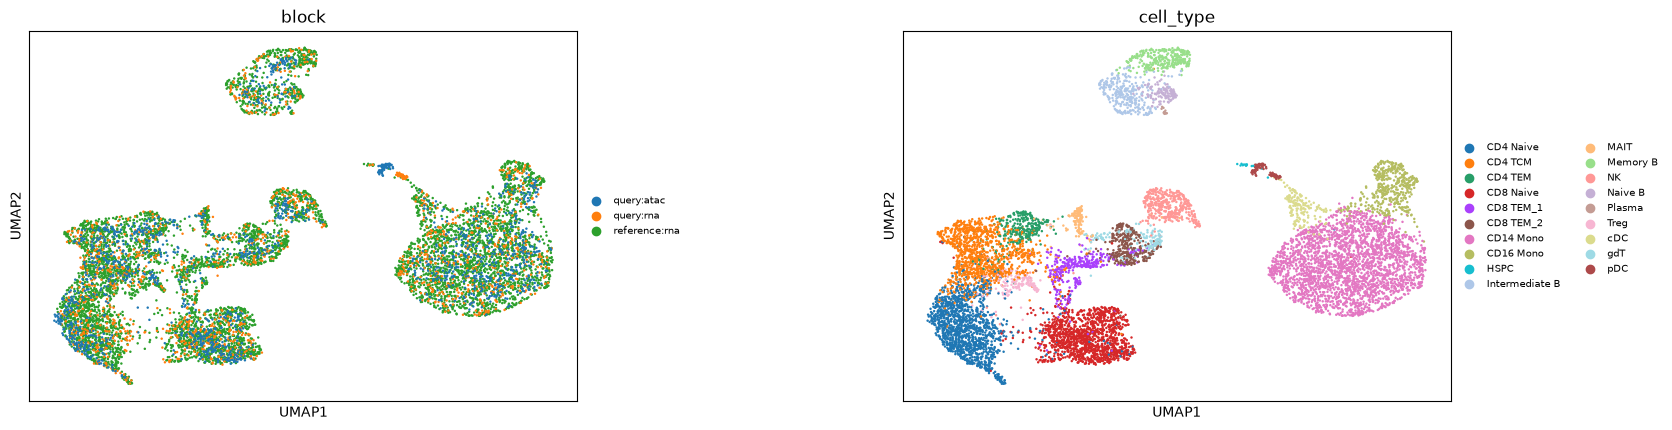

In [7]:
joint = stack_embeddings(model, [("reference", "rna", ref["rna"]), ("query", "rna", q_rna),
                                 ("query", "atac", q_atac)], device=device)
sc.pp.neighbors(joint, use_rep="X_univi", n_neighbors=30)
sc.tl.umap(joint, random_state=0)
sc.pl.umap(joint, color=["block", "cell_type"], wspace=0.45, legend_fontsize=7)

## Transfer labels with a confidence score

A k-nearest-neighbor vote in latent space assigns each query cell the most common reference label among its neighbors. The fraction of neighbors that agree is a simple confidence score, and the mean distance to those neighbors indicates how well the reference covers the cell.

In [8]:
knn = KNeighborsClassifier(n_neighbors=15).fit(z_ref, ref["rna"].obs["cell_type"].astype(str))

def transfer(z):
    proba = knn.predict_proba(z)
    dist = knn.kneighbors(z)[0].mean(axis=1)
    return pd.DataFrame({"predicted": knn.classes_[proba.argmax(1)], "confidence": proba.max(1), "distance": dist})

results = {}
for name, z, cells in [("RNA-only", z_q_rna, q_rna), ("ATAC-only", z_q_atac, q_atac)]:
    df = transfer(z)
    df["true"] = cells.obs["cell_type"].astype(str).to_numpy()
    results[name] = df
    seen = df["true"] != HOLDOUT_TYPE
    print(f"{name}: accuracy on cell types present in the reference = {(df.predicted == df.true)[seen].mean():.3f}")

RNA-only: accuracy on cell types present in the reference = 0.933
ATAC-only: accuracy on cell types present in the reference = 0.924


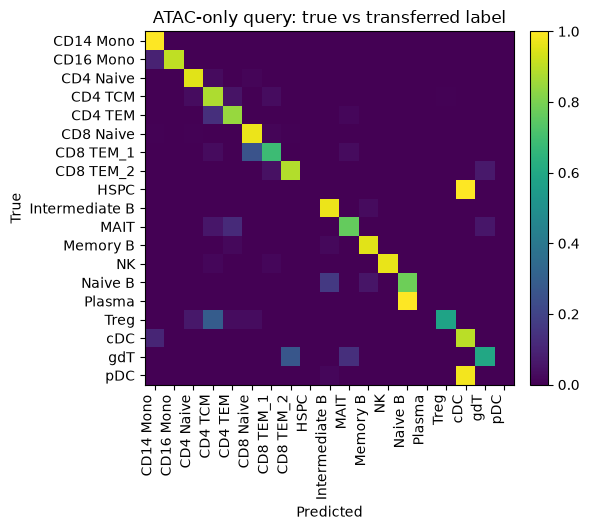

In [9]:
df = results["ATAC-only"]
order = sorted(set(df["true"]) | set(df["predicted"]))
cm = confusion_matrix(df["true"], df["predicted"], labels=order)
plot_confusion_matrix(cm, labels=order, normalize="true", title="ATAC-only query: true vs transferred label")

The held-out cell type cannot receive its own label (the reference has never seen it), so it is assigned to its nearest relative. Its confidence and distance scores are what give it away. Thresholds on these scores are a practical way to flag cells for review:

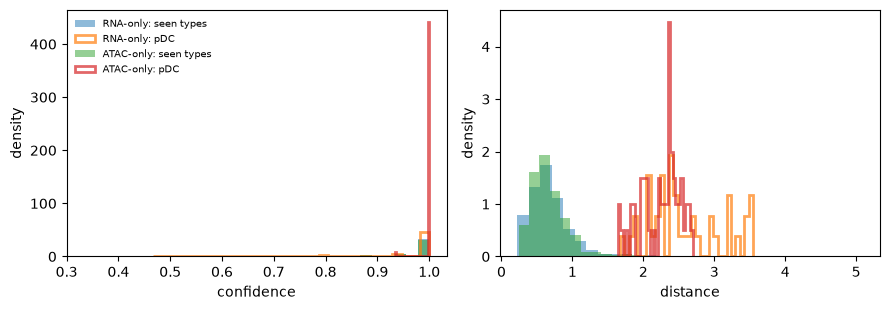

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, col in zip(axes, ["confidence", "distance"]):
    for name, df in results.items():
        is_new = df["true"] == HOLDOUT_TYPE
        ax.hist(df.loc[~is_new, col], bins=30, alpha=0.5, density=True, label=f"{name}: seen types")
        ax.hist(df.loc[is_new, col], bins=30, alpha=0.7, density=True, histtype="step", lw=2,
                label=f"{name}: {HOLDOUT_TYPE}")
    ax.set(xlabel=col, ylabel="density")
axes[0].legend(fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

## Predict the missing modality

For the ATAC-only cohort, decoding RNA from the ATAC embedding predicts gene expression. Because these cells were actually measured with RNA too, we can check the prediction.

In [11]:
predicted_rna = cross_modal_predict(model, q_atac, src_mod="atac", tgt_mod="rna", device=device)
truth = rna_prep.transform(rna[atac_only_idx])            # hidden RNA of the same cells
r = pd.Series(pearson_corr_per_feature(np.asarray(truth.X), predicted_rna), index=truth.var_names)
print(f"ATAC to RNA, median per-gene Pearson r = {r.median():.3f}")
r.sort_values(ascending=False).head(10).round(3)

ATAC to RNA, median per-gene Pearson r = 0.228


genes
FCRL1     0.927
PAX5      0.923
MS4A1     0.906
SLC8A1    0.903
EBF1      0.894
LYN       0.889
ZEB2      0.887
PLXDC2    0.887
LRMDA     0.881
LEF1      0.875
dtype: float32

## Using your own query data

The preprocessors refuse queries that lack reference features, rather than silently filling them. Check coverage first:

```python
missing = pd.Index(rna_prep.features_).difference(my_query.var_names)
print(len(missing), "reference genes missing from the query")
```

- **RNA**: match gene identifiers (symbols vs Ensembl IDs, and the annotation version) before transforming. If a few genes are missing, the cleanest fix is to refit the reference on the genes both datasets share. Zero-filling missing genes makes them look unexpressed and biases the embedding.
- **ATAC**: query accessibility must be counted on the **reference peak set** (for example, re-quantify query fragments over the reference peaks with Signac's `FeatureMatrix` or SnapATAC2). Peaks called separately on the query are not interchangeable, even if their number matches.
- **Batch effects**: a query from a different lab or chemistry may land slightly offset from the reference. Label transfer is often still robust; the confidence and distance scores above help you judge. For supervised adaptation, see [Cell-type heads and refinement](supervised_heads.ipynb).